# Homework09

Exercises to practice dimensionality reduction with PCA

## Goals

- Add unsupervised pre-processing to our ML flow: encode -> normalize -> pre-process -> train -> evaluate
- Build an intuition for PCA and when/how to use it
- Understand the benefits of dimensionality reduction

### Setup

Run the following 2 cells to import all necessary libraries and helpers for this homework.

In [3]:
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/image_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/Homework07/raw/main/Homework07_utils.pyc

!wget -qO- https://github.com/PSAM-5020-2026S-A/5020-utils/releases/latest/download/0801-500.tar.gz | tar xz

In [4]:
from os import listdir, path
from PIL import Image as PImage

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

from image_utils import get_pixels, make_image

from Homework07_utils import CamUtils

## PCA and Classification

Let's practice doing some more image classification with `PCA` and analyzing the results.

The dataset is the same one we used in `Homework07`. It has images from $25$ different security cameras, and our task is to separate them by camera. Some of the cameras move, some of them don't, and there are more than $1000$ images, so there's no way we want to do this by hand.

Let's start by loading the training images into a list of pixels, like we did with the `faces` dataset in class.

### Loading Data

If we look at the images in `./data/image/0801-500/train/`, we'll notice that they are named and organized in a slightly different way. They're all in the same directory and the first part of their filename specifies which camera they came from. Even though those `ids` are numbers, they're not sequential, so we'll use some helper functions to extract a unique `label` from their filenames.

This is exactly what the `OrdinalEncoder` class does, but since we only have to encode this one column, we'll do it by hand while we read the files in.

In [5]:
# this creates a list of all the files in a given directory, that end in .jpg
train_files = [f for f in listdir("./data/image/0801-500/train") if f.endswith(".jpg")]


In [6]:
# TODO: check and see what is inside the list here
display(train_files[:3])


['13-04.jpg', '02-24.jpg', '24-10.jpg']

Now we'll read the image pixels and extract their labels. `CamUtils.get_label()` is the helper function we'll use to "encode" and return a label id based on the filename.

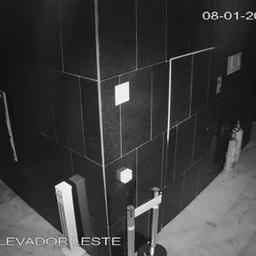

11

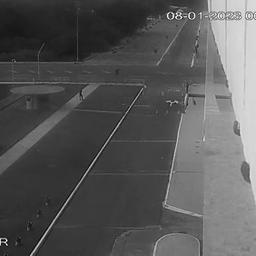

1

In [7]:

pixel_data = []
label_data = []

for fname in train_files:
  label = CamUtils.get_label(fname)
  img = PImage.open(path.join("./data/image/0801-500/train", fname))
  pixel_data.append(get_pixels(img))
  label_data.append(label)

iw = img.size[0]

display(make_image(pixel_data[0], width=iw),label_data[0])
display(make_image(pixel_data[1], width=iw),label_data[1])

In [8]:

# TODO: check if labels got extracted correctly by looking at 
#       the first few items of the label list and the filename list

print(label_data[:5])
print(train_files[:5])


[11, 1, 19, 4, 14]
['13-04.jpg', '02-24.jpg', '24-10.jpg', '06-37.jpg', '18-57.jpg']


Like in `Homework07`, the labels and the filenames won't match exactly since labels start at $0$ and the filenames start at $01$ and skip some numbers.

We can open some images from pixels, just to make sure we loaded them correctly:

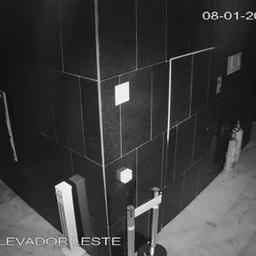

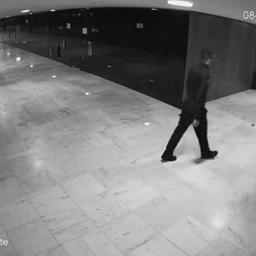

In [9]:

display(make_image(pixel_data[0]))
display(make_image(pixel_data[10]))

### PCA

Create a `DataFrame` called `cam_pca_df` by running `PCA` on the list of pixel data, just like we did in class, and then append a `label` column to it, just like we did in Homework07 with: `train_df["label"] = label_data`.

You can change how many components to extract from the images later, but for this first run just use $10$ components so we can compare classification with $10$ `PCA` components to the classification with $10$ random features from `Homework07`.  Make sure to confirm how much of the `variance` is preserved by this transformation.

In [10]:
# TODO: run PCA, get DataFrame
pca = PCA(n_components=12).set_output(transform="pandas")
img_df = pca.fit_transform(pixel_data)
# TODO: add "label" column
img_df["label"] = label_data
# TODO: print variance
print(sum(pca.explained_variance_ratio_))
# TODO: take a look at the first 5 rows
display(img_df[:5])

0.8154083580886528


,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,pca10,pca11,label
0,-6439.367164,-10685.487153,-393.245868,699.026243,1202.629551,-4966.236400,5179.950706,709.958709,1783.941191,381.993053,-1756.054009,-410.256381,11
1,-5615.496419,-2789.052923,9526.371322,107.638410,-4238.415351,1035.391078,1214.800342,-1800.311379,2660.125628,-757.578564,-710.569772,-582.897520,1
2,-8648.767151,-5391.152216,5267.286137,-1364.622300,-3260.492821,-1395.594621,-476.825443,-3354.122085,1232.937391,1676.802066,-130.985511,-1069.874180,19
3,2017.741255,10999.238500,-921.293870,-7848.899572,-3105.918363,3922.549276,7171.793892,-3125.985461,-770.335737,2843.479667,486.203763,666.756753,4
4,6193.021328,3488.275302,-13535.361723,-2919.270338,-3227.338318,2295.215754,-1845.725180,-1871.157607,105.412407,-2602.771241,-2812.347104,1004.996290,14


### Interpretation

<span style="color:hotpink">
How many components did you keep ?<br>
Did you try different numbers ?<br>
What percent of variance is kept by this transformation?
</span>

<span style="color:hotpink;">
10 components --> 0.785 variance <br>
12 components --> 0.815 variance <br>
15 components --> 0.850 variance <br>
</span>

### Reconstruct

Before we go run our classification, let's take a look at some reconstructed images, just to make sure they make sense.

Take a look at reconstructed versions of images $0$, $10$, and whichever other images you might have opened above.

We did this in class. It involves a `inverse_transform()` function.

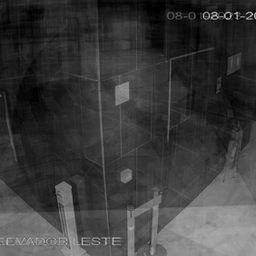

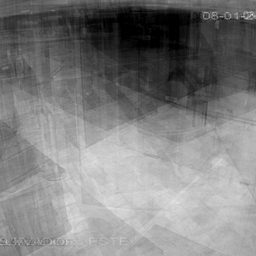

In [11]:
img_pixel = img_df.drop(columns=["label"]).values
# TODO: reconstruct image at index 0
pca_re_0 = pca.inverse_transform(img_pixel[0:1])

# TODO: reconstruct image at index 10
pca_re_10 = pca.inverse_transform(img_pixel[10:11])

display(make_image(pca_re_0))
display(make_image(pca_re_10))

The reconstructed images should look blurrier and noisier than the original ones, but they should still look something like the original ones.

### Classify !

Train a `RandomForestClassifier` on the `PCA` data.

Remember to separate the output feature (`label`) from the input features (`PC0`, `PC1`, etc).

In [12]:
# TODO: create a classifier
rf_classifier = RandomForestClassifier(random_state=1100)
# TODO: split input and output features
input = img_df.drop(columns=["label"])
output = img_df["label"]
# TODO: fit the model
rf_classifier.fit(input, output)



# TODO: run predictions
train_predictions = rf_classifier.predict(input) 

### Measure Error

For the train set we could use the generic `classification_error()` function that we've used before because we have the true labels for each file, but for measuring accuracy for our `test` set classification, which has secret labels, we have to use a more specific function from the `CamUtils` class.

The function is called `classification_accuracy()` and it takes $2$ parameters, a list of filenames and the predicted labels associated with those filenames.

The result is an accuracy score ratio, between $0.0$ and $1.0$.

We can run this function on the `train` set as well:

In [13]:
# train_files is the list of files we got way up above
CamUtils.classification_accuracy(train_files, train_predictions)

1.0

### Interpretation

<span style="color:hotpink">
What does this mean?<br>
Should we expect the same result from the test dataset?<br>
Why, or why not?
</span>

<span style="color:hotpink;">
1. The model achieved 100% accuracy on the training data <br>
2. Usually we cannot. The model is likely overfitting the training data. <br>
</span>

### Run on Test set

Now we'll open the image files inside the `./data/image/0801-500/test/` directory, using almost the exact same steps as we did above to create a `DataFrame` with the exception that we don't have labels for these images.

In [14]:
# TODO: create a list of files in the test/ directory
test_files = [f for f in listdir("./data/image/0801-500/test") if f.endswith(".jpg")]

# TODO: check its length and content
display(test_files[:5]) 
display(len(test_files))

['7176838.jpg', '5838086.jpg', '12423813.jpg', '8717209.jpg', '6870122.jpg']

1573

We'll use a similar loop to extract the pixel information from these images, except we don't have `label` data, just pixels.

In [ ]:
test_pixel_data = []

for fname in test_files:
  img = PImage.open(path.join("./data/image/0801-500/test", fname))
  test_pixel_data.append(get_pixels(img))

: 

Now we can run `PCA` and the `RandomForestClassifier`.

Since those are already trained, all we have to do is run their `transform()` function on the data.

In [ ]:
# TODO: run PCA on test pixels, get DataFrame
#       this is the same PCA that was created above, not a new one
test_img_df = pca.fit_transform(test_pixel_data)

test_predictions = rf_classifier.predict(test_img_df) 

: 

It's always a good idea to check the result of the `PCA` transformation by looking at the `DataFrame` and reconstructing some images.

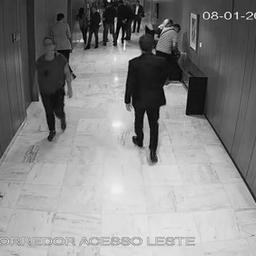

NameError: name 'test_img_df' is not defined

In [ ]:
# TODO: reconstruct one or two images
display(make_image(test_pixel_data[0]))
recons_0 = pca.inverse_transform(test_img_df[0:1])
display(make_image(recons_0))

display(make_image(test_pixel_data[5]))
recons_1 = pca.inverse_transform(test_img_df[5:6])
display(make_image(recons_1))
# TODO: take a look at the first 5 rows
display(test_img_df[:5])

### Interpretation

<span style="color:hotpink"><br>
The reconstructed images from the `test` set will always be noisier than the `train` images.<br><br>
Why?<br><br>
</span>

<span style="color:hotpink;">The 12 PCA components fit the training data well, 
but the test data contains patterns the PCA didn't fully learn, 
leading to more information loss and noisier reconstructions</span>



Run the classifier and get predicted labels. Then get its accuracy ratio is by running the `CamUtils.classification_accuracy()` function with the list of filenames and list of predictions.

In [ ]:
# TODO: run classifier. This is the same classifier already fitted on the train data above

test_predictions_rf = rf_classifier.predict(test_img_df)

# TODO: get accuracy
CamUtils.classification_accuracy(test_files, test_predictions_rf)

0.41640178003814365

: 

### Interpretation

<span style="color:hotpink">
What's the accuracy ? How could we improve that if we wanted ?<br>
How does this compare to the classification model from <code>Homework07</code>? They can both be tuned to perform well, but how many features did we need last time in order to get an accuracy comparable to this?
</span>

<span style="color:hotpink;">
1. The accuracy is 0.416. we can introduce more components in PCA
2. The claasification model from HW07 has a highter accuracy, but it used 120 features. 
</span>